In [1]:
# load processed df
from IPython.utils.capture import capture_output

with capture_output():
    %run data_loading.ipynb

# Sample a few good and a few bad and plot their balance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_merged = accounts.merge(consumers[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id')
df_merged.isna().sum()

prism_consumer_id       0
prism_account_id        0
account_type            0
balance_date            0
balance                 0
DQ_TARGET            4979
dtype: int64

In [3]:
df_clean = df_merged.dropna(subset=['DQ_TARGET']).copy()

In [4]:
# Separate IDs by DQ_TARGET
good_ids = df_clean[df_clean['DQ_TARGET'] == 0]['prism_consumer_id'].unique()
bad_ids = df_clean[df_clean['DQ_TARGET'] == 1]['prism_consumer_id'].unique()

# Randomly Sample 5 IDs from each group
sample_good = pd.Series(good_ids).sample(5, random_state = 111).tolist()
sample_bad = pd.Series(bad_ids).sample(5, random_state = 111).tolist()

# Filter the accounts data for these 10 users
plot_data = df_clean[df_clean['prism_consumer_id'].isin(sample_good + sample_bad)].copy()
plot_data

,prism_consumer_id,prism_account_id,account_type,balance_date,balance,DQ_TARGET
5234,1375,5234,CHECKING,2021-12-31,2000.36,0.0
7526,3823,7526,CHECKING,2021-09-30,355.76,0.0
8439,2559,8439,SAVINGS,2021-10-31,664.28,0.0
8440,2559,8440,CHECKING,2021-10-31,8444.45,0.0
8441,2559,8441,CHECKING,2021-10-31,5275.02,0.0
9974,7986,9974,CHECKING,2023-09-08,564.23,1.0
10280,5033,10280,CHECKING,2023-05-23,2.91,1.0
13471,5842,13471,CHECKING,2023-10-28,20.45,1.0
14203,6834,14203,CHECKING,2023-01-16,122.01,1.0
14843,8093,14843,CHECKING,2023-10-03,25444.89,0.0


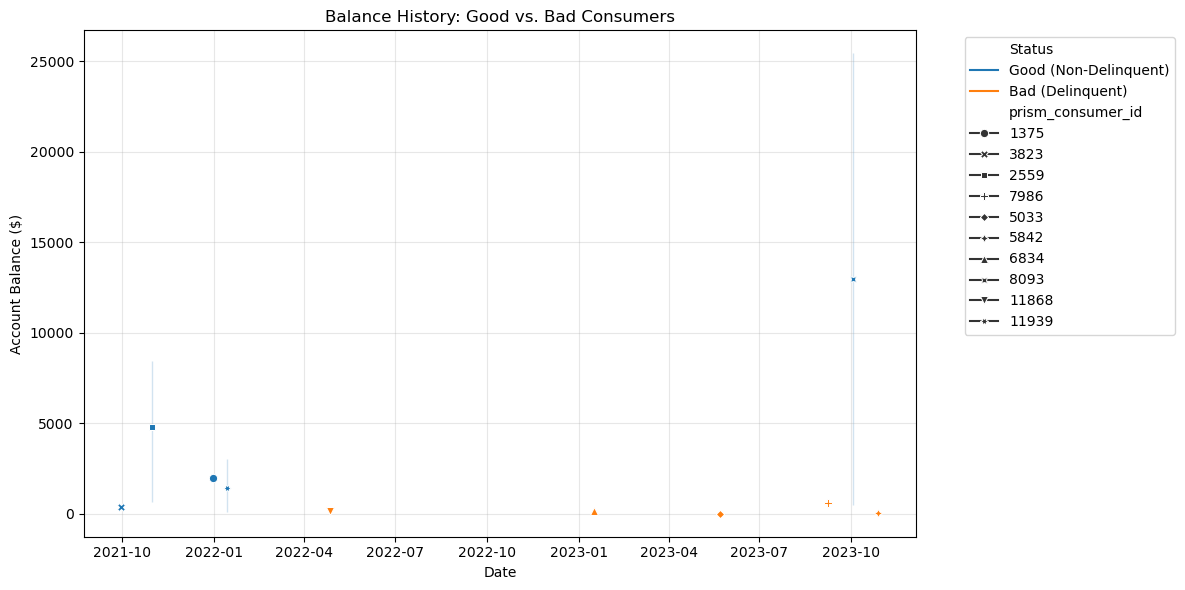

In [5]:
# Add a readable label for the legend
plot_data['Status'] = plot_data['DQ_TARGET'].map({0: 'Good (Non-Delinquent)', 1: 'Bad (Delinquent)'})
plot_data['balance_date'] = pd.to_datetime(plot_data['balance_date'])

# Plot the Balance Trends
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_data, 
    x='balance_date', 
    y='balance', 
    hue='Status', 
    style='prism_consumer_id', # Different line style for each specific user
    markers=True,
    dashes=False
)

plt.title('Balance History: Good vs. Bad Consumers')
plt.ylabel('Account Balance ($)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Check the balances for good and bad as a whole

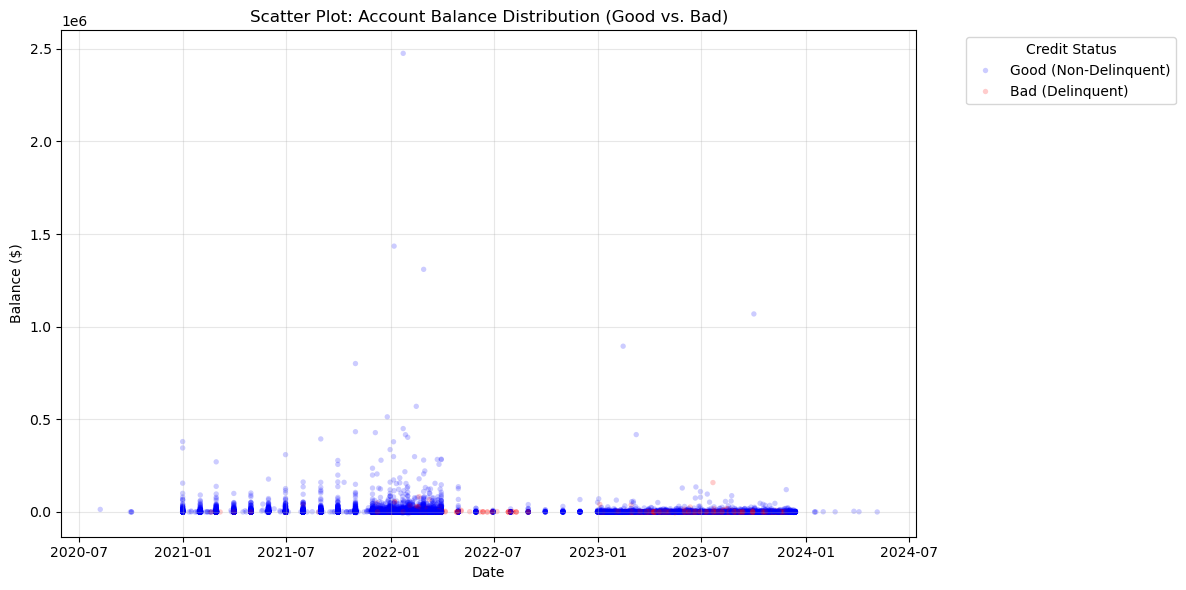

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_clean['Status'] = df_clean['DQ_TARGET'].map({0: 'Good (Non-Delinquent)', 1: 'Bad (Delinquent)'})

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_clean,
    x='balance_date',
    y='balance',
    hue='Status',
    alpha=0.2,       # transparency
    s=15,            # size
    linewidth=0,
    palette={'Good (Non-Delinquent)': 'blue', 'Bad (Delinquent)': 'red'}
)

plt.title('Scatter Plot: Account Balance Distribution (Good vs. Bad)')
plt.xlabel('Date')
plt.ylabel('Balance ($)')
plt.grid(True, alpha=0.3)
plt.legend(title='Credit Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
df_clean['balance'].max()

2475000.0

# Burn rate feature based on transaction

In [29]:
is_income = (transactions['credit_or_debit'] == 'CREDIT')
is_spending = (transactions['credit_or_debit'] == 'DEBIT')

# temporary columns
transactions['calc_income'] = np.where(is_income, transactions['amount'], 0)
transactions['calc_spending'] = np.where(is_spending, transactions['amount'], 0)

# Aggregate per Consumer
burn_rate_stats = transactions.groupby('prism_consumer_id')[['calc_income', 'calc_spending']].sum().reset_index()

# 4. Calculate the Ratio (Spend / Income)
# Logic for Edge Cases:
# - If Income is 0 but Spending > 0: Infinite Risk. We cap this at a high number (e.g., 10.0 or 1000%)
# - If Income is 0 and Spending is 0: No Activity. Set to 0.
burn_rate_stats['burn_rate'] = np.where(
    burn_rate_stats['calc_income'] == 0,
    np.where(burn_rate_stats['calc_spending'] == 0, 0, 10.0), # Cap infinite risk at 10.0
    burn_rate_stats['calc_spending'] / burn_rate_stats['calc_income']
)

# 5. Merge and Fill
# We merge back to consumers to ensure we have a row for everyone
df_burn_rate = consumers[['prism_consumer_id']].merge(burn_rate_stats, on='prism_consumer_id', how='left')

# Fill users with NO transactions as 0 (or you could choose a neutral value like 1.0)
# df_burn_rate['burn_rate'] = df_burn_rate['burn_rate'].fillna(0)

print(df_burn_rate[['prism_consumer_id', 'burn_rate']].head())

  prism_consumer_id  burn_rate
0                 0   1.036255
1                 1   0.927504
2                 2   0.981105
3                 3   0.876542
4                 4   1.169957


In [19]:
df_burn_rate['burn_rate'].describe()

count    14492.000000
mean        11.208443
std        613.424708
min          0.000000
25%          0.914322
50%          0.991756
75%          1.029284
max      57142.857143
Name: burn_rate, dtype: float64

In [30]:
df_burn_rate[df_burn_rate['burn_rate']>57142]

,prism_consumer_id,calc_income,calc_spending,burn_rate
3749,3749,0.07,4000.0,57142.857143


In [28]:
df_clean[df_clean['prism_consumer_id']=="3749"]

,prism_consumer_id,prism_account_id,account_type,balance_date,balance,DQ_TARGET,Status
8174,3749,8174,SAVINGS,2021-08-31,225.16,0.0,Good (Non-Delinquent)


In [31]:
transactions[transactions['prism_consumer_id']=="3749"]

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date,calc_income,calc_spending
1300038,3749,1298525,4,0.07,CREDIT,2021-02-16,0.07,0.0
1300039,3749,1298526,45,4000.00,DEBIT,2021-02-16,0.00,4000.0


In [35]:
# Log Transformation
df_burn_rate['log_burn_rate'] = np.log1p(df_burn_rate['burn_rate'])

print("\n--- Log Stats ---")
print(df_burn_rate['log_burn_rate'].describe())


--- Log Stats ---
count    14492.000000
mean         0.669157
std          0.323650
min          0.000000
25%          0.649363
50%          0.689017
75%          0.707683
max         10.953327
Name: log_burn_rate, dtype: float64


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# Merge with Target
df_eval = df_burn_rate.merge(consumers[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id')
df_eval = df_eval.dropna(subset=['DQ_TARGET'])

# Replace Infinity with NaN
df_eval['log_burn_rate'] = df_eval['log_burn_rate'].replace([np.inf, -np.inf], np.nan)

# Fill NaN with 0 (or the Median)
# Using 0 is safe here because log(burn_rate + 1) of 0 means "0 burn rate" (didn't spend anything).
df_eval['log_burn_rate'] = df_eval['log_burn_rate'].fillna(0)

# Run Logistic Regression
X = df_eval[['log_burn_rate']]
y = df_eval['DQ_TARGET']

clf = LogisticRegression()
clf.fit(X, y)
y_pred_proba = clf.predict_proba(X)[:, 1]

# Calculate Metrics
auc = roc_auc_score(y, y_pred_proba)

# KS Calculation
probs_bad = y_pred_proba[y == 1]
probs_good = y_pred_proba[y == 0]
ks_stat, _ = ks_2samp(probs_bad, probs_good)

print(f"Feature: Log Burn Rate")
print(f"AUC Score: {auc:.4f}")
print(f"KS Statistic: {ks_stat:.4f}")

Feature: Log Burn Rate
AUC Score: 0.5503
KS Statistic: 0.1470


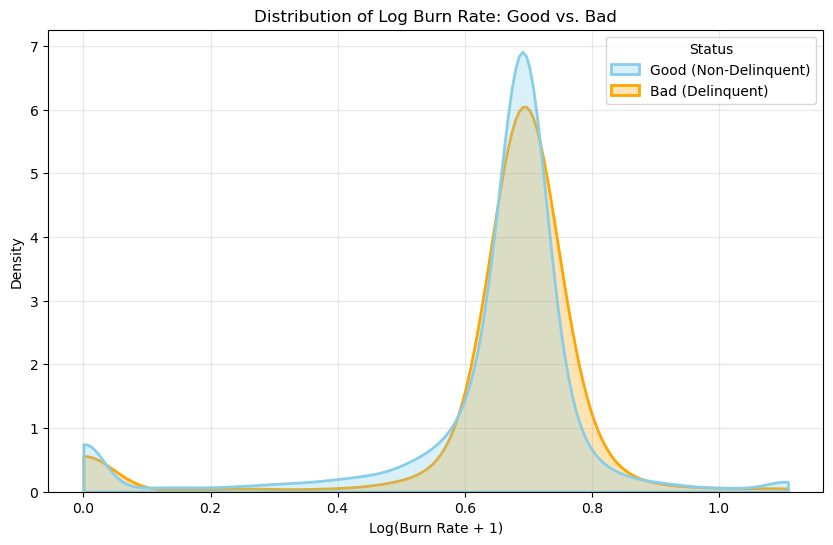

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = df_eval.copy()
plot_data['Status'] = plot_data['DQ_TARGET'].map({0: 'Good (Non-Delinquent)', 1: 'Bad (Delinquent)'})

# extreme value
upper_limit = plot_data['log_burn_rate'].quantile(0.99)
plot_data['log_burn_rate_viz'] = plot_data['log_burn_rate'].clip(upper=upper_limit)

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=plot_data,
    x='log_burn_rate_viz',
    hue='Status',
    fill=True,
    common_norm=False,
    palette={'Good (Non-Delinquent)': 'skyblue', 'Bad (Delinquent)': 'orange'},
    alpha=0.3,
    linewidth=2,
    cut=0
)

plt.title('Distribution of Log Burn Rate: Good vs. Bad')
plt.xlabel('Log(Burn Rate + 1)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()